I. IMPORT LIBRARY DAN PENYIAPAN LINGKUNGAN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Konfigurasi visualisasi
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

II. DATA ACQUISITION (LOAD DATASET)

In [2]:
# Memuat data Brent Oil dari folder data
df = pd.read_csv('../data/BrentOilPrices.csv')

# Menampilkan dimensi data dan 5 baris pertama
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
df.head()

Jumlah baris: 9011, Jumlah kolom: 2


,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


III. EXPLORATORY DATA ANALYSIS (EDA) & DATA CLEANING

In [3]:
# 1. Cek Missing Values & Tipe Data
print("Pengecekan Missing Values:")
print(df.isnull().sum())

# 2. Konversi Tipe Data Date (Wajib untuk Time Series)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# 3. Statistik Deskriptif
print("\nStatistik Deskriptif:")
display(df.describe())

Pengecekan Missing Values:
Date     0
Price    0
dtype: int64


C:\Users\WIGISS\AppData\Local\Temp\ipykernel_4372\1262029066.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])



Statistik Deskriptif:


,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


IV. VISUALISASI DATA (DATA VISUALIZATION)

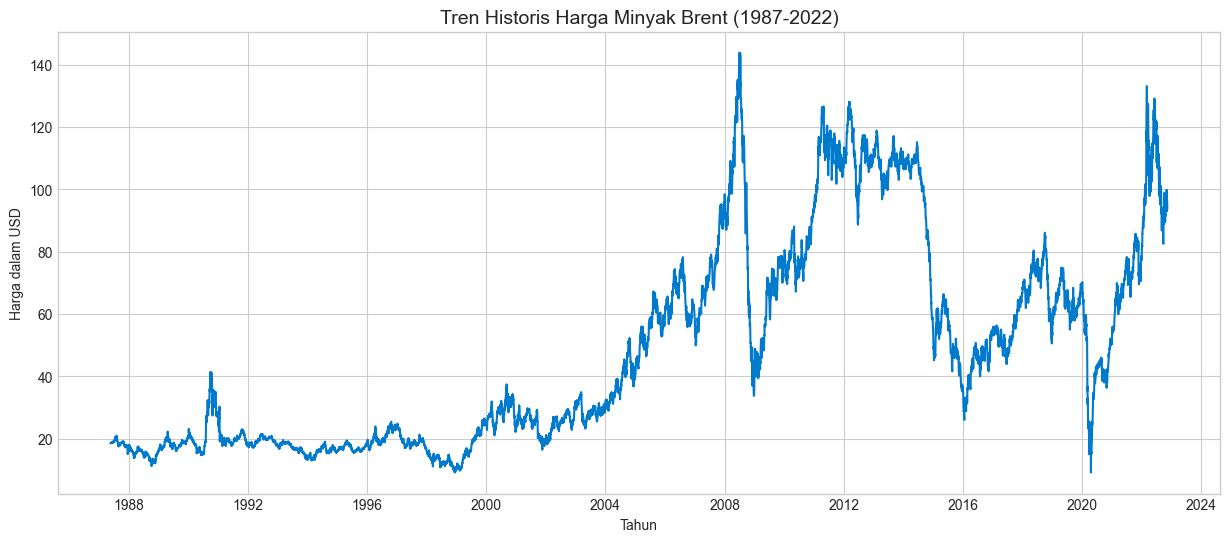

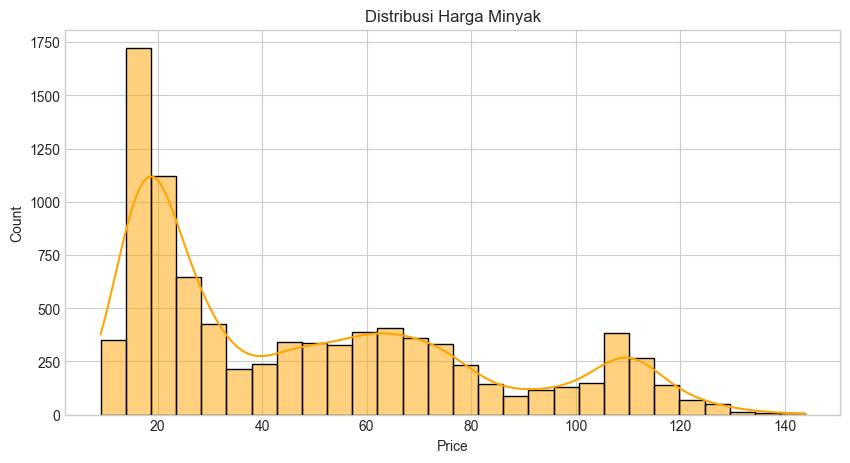

In [4]:
# Line Chart Tren Harga Historis
plt.figure(figsize=(15, 6))
plt.plot(df['Date'], df['Price'], color='#007acc')
plt.title('Tren Historis Harga Minyak Brent (1987-2022)', fontsize=14)
plt.xlabel('Tahun')
plt.ylabel('Harga dalam USD')
plt.show()

# Histogram Distribusi Harga
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], kde=True, color='orange')
plt.title('Distribusi Harga Minyak')
plt.show()

V. DATA PREPROCESSING UNTUK MODELING

Penjelasan: Di sini kita akan membuat fitur 'Lag' (harga hari sebelumnya) untuk membantu algoritma Linear Regression dan Neural Network memprediksi harga hari ini.

In [5]:
# Membuat Fitur Lag-1 (Harga hari sebelumnya)
df['Price_Lag1'] = df['Price'].shift(1)

# Menghapus baris pertama yang menjadi NaN karena proses shifting
df_model = df.dropna().copy()

# Membagi fitur (X) dan target (y)
X = df_model[['Price_Lag1']]
y = df_model['Price']

# Split Data: 80% Training, 20% Testing (Sesuai Ketentuan UTS)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")

Jumlah data training: 7208
Jumlah data testing: 1802


VI. IMPLEMENTASI ALGORITMA 1: LINEAR REGRESSION

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Inisialisasi dan Training
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediksi
y_pred_lr = lr_model.predict(X_test)

# Evaluasi
print(f"MAE  : {mean_absolute_error(y_test, y_pred_lr)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr))}")
print(f"R2   : {r2_score(y_test, y_pred_lr)}")

MAE  : 1.1299629535495264
RMSE : 1.700356686514875
R2   : 0.9932110174613805


VII. IMPLEMENTASI ALGORITMA 2: K-MEANS CLUSTERING

Penjelasan: Algoritma ini digunakan untuk mengelompokkan hari-hari perdagangan berdasarkan tingkat harga. Kita akan mencari "zona harga" (misal: zona harga rendah, sedang, dan tinggi).

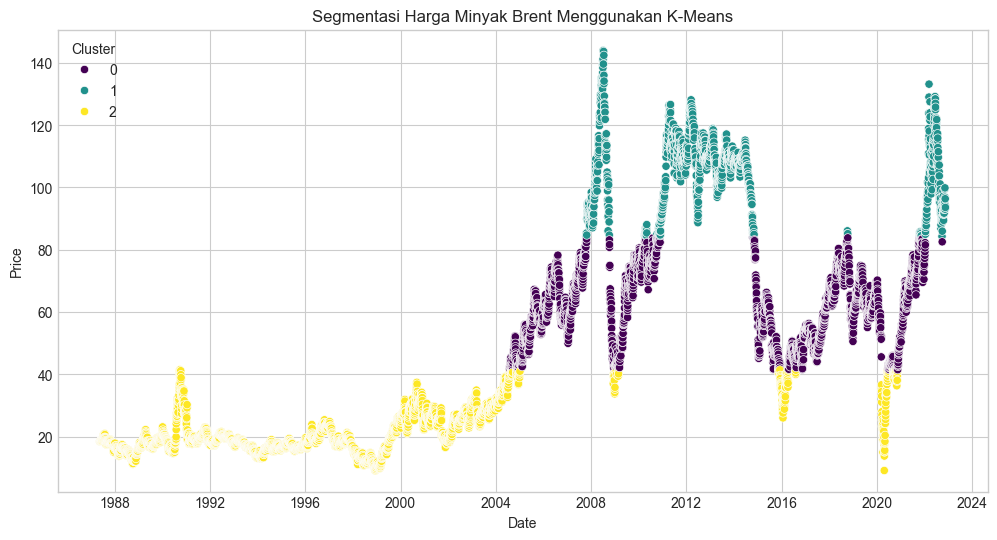

Pusat Cluster (Centroids):
[[ 61.50317851]
 [106.95881208]
 [ 21.46617907]]


In [7]:
from sklearn.cluster import KMeans

# Mengambil data harga untuk clustering
X_cluster = df_model[['Price']].values

# Menentukan jumlah cluster (misal: 3 untuk Rendah, Sedang, Tinggi)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_model['Cluster'] = kmeans.fit_predict(X_cluster)

# Visualisasi Hasil Clustering
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_model['Date'], y=df_model['Price'], hue=df_model['Cluster'], palette='viridis')
plt.title('Segmentasi Harga Minyak Brent Menggunakan K-Means')
plt.show()

print("Pusat Cluster (Centroids):")
print(kmeans.cluster_centers_)

VIII. PREPROCESSING LANJUTAN: SCALING DATA

Penjelasan: Model Neural Network (ANN & LSTM) sangat sensitif terhadap skala data. Kita akan mengubah rentang harga menjadi 0 sampai 1 menggunakan MinMaxScaler.

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Inisialisasi Scaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_model[['Price']])

# Fungsi untuk membuat struktur data time series (look-back)
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Kita gunakan look_back = 30 hari (memprediksi berdasarkan 1 bulan terakhir)
look_back = 30
X_series, y_series = create_dataset(scaled_data, look_back)

# Split data 80:20
train_size = int(len(X_series) * 0.8)
X_train_dl, X_test_dl = X_series[:train_size], X_series[train_size:]
y_train_dl, y_test_dl = y_series[:train_size], y_series[train_size:]

print(f"Struktur data untuk Deep Learning: {X_train_dl.shape}")

Struktur data untuk Deep Learning: (7183, 30)


IX. IMPLEMENTASI ALGORITMA 3: ARTIFICIAL NEURAL NETWORK (ANN)

c:\Users\WIGISS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.2820e-04 - val_loss: 4.0586e-04
Epoch 2/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.7842e-04 - val_loss: 2.1408e-04
Epoch 3/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4949e-04 - val_loss: 5.8033e-04
Epoch 4/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.7852e-04 - val_loss: 1.4572e-04
Epoch 5/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4609e-04 - val_loss: 5.0008e-04
Epoch 6/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.3604e-04 - val_loss: 6.9713e-04
Epoch 7/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4496e-04 - val_loss: 8.5329e-04
Epoch 8/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.3085e-04 - val_loss: 8.6655e-04
Epoch 9/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5040e-04 - val_loss: 1.2926e-04
Epoch 10/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2324e-04 - val_loss: 1.4721e-04
Epoch 11/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss

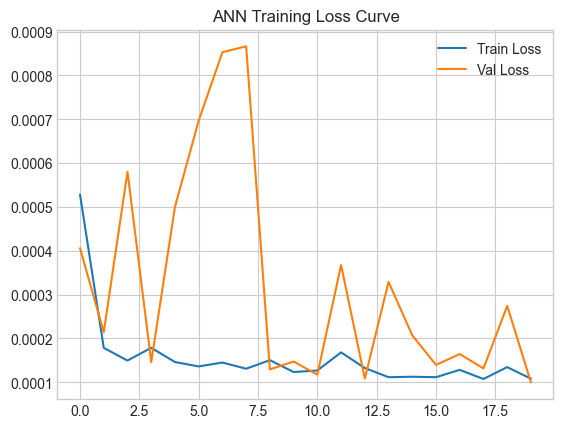

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Membangun Arsitektur ANN
ann_model = Sequential([
    Dense(64, activation='relu', input_dim=look_back),
    Dense(32, activation='relu'),
    Dense(1) # Output layer untuk regresi
])

ann_model.compile(optimizer='adam', loss='mean_squared_error')

# Training Model
history_ann = ann_model.fit(X_train_dl, y_train_dl, epochs=20, batch_size=32, 
                            validation_split=0.1, verbose=1)

# Visualisasi Training Loss
plt.plot(history_ann.history['loss'], label='Train Loss')
plt.plot(history_ann.history['val_loss'], label='Val Loss')
plt.title('ANN Training Loss Curve')
plt.legend()
plt.show()

X. IMPLEMENTASI ALGORITMA 4: RECURRENT NEURAL NETWORK (RNN / LSTM)

Epoch 1/20


c:\Users\WIGISS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0038 - val_loss: 8.4742e-04
Epoch 2/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 3/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0010 - val_loss: 8.2258e-04
Epoch 4/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0010 - val_loss: 0.0013
Epoch 5/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 8.8456e-04 - val_loss: 0.0014
Epoch 6/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.1697e-04 - val_loss: 4.8231e-04
Epoch 7/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7.3132e-04 - val_loss: 8.0108e-04
Epoch 8/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7.7421e-04 - val_loss: 5.9103e-04
Epoch 9/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7.3020e-04 - val_loss: 3.3679e-04
Epoch 10/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 6.8160e-04 - val_loss: 3.0001e-04
Epoch 11/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 6.7305e-04 - val_loss: 4.7735e-04
Ep

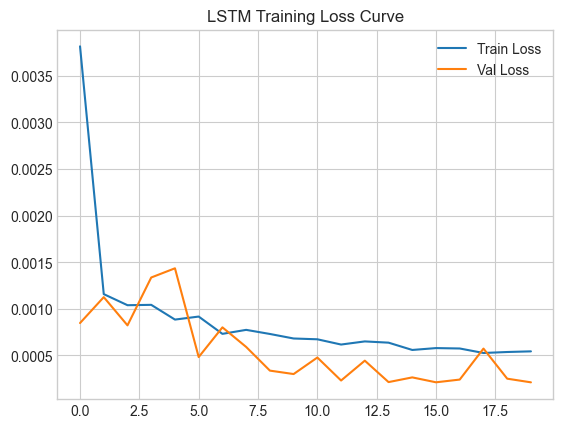

In [10]:
from tensorflow.keras.layers import LSTM, Dropout

# Reshape input menjadi [samples, time steps, features] khusus untuk LSTM
X_train_lstm = np.reshape(X_train_dl, (X_train_dl.shape[0], X_train_dl.shape[1], 1))
X_test_lstm = np.reshape(X_test_dl, (X_test_dl.shape[0], X_test_dl.shape[1], 1))

# Membangun Arsitektur LSTM
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Training Model
history_lstm = lstm_model.fit(X_train_lstm, y_train_dl, epochs=20, batch_size=32, 
                              validation_split=0.1, verbose=1)

# Visualisasi Training Loss
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Loss Curve')
plt.legend()
plt.show()

XI. IMPLEMENTASI ALGORITMA 5: BACKPROPAGATION MODEL (MANUAL NUMPY)

Penjelasan: Di sini kita membangun Neural Network dari nol menggunakan NumPy untuk menunjukkan pemahaman alur maju (forward) dan pembaruan bobot (backward) sesuai instruksi tugas.

In [15]:
# --- Penyesuaian Agar Tidak NaN ---
# Gunakan StandardScaler sederhana (mean 0, std 1) agar data lebih stabil
X_mean, X_std = X_train.mean().values, X_train.std().values
y_mean, y_std = y_train.mean(), y_train.std()

X_bp_scaled = (X_train.values - X_mean) / X_std
y_bp_scaled = (y_train.values.reshape(-1, 1) - y_mean) / y_std

# Inisialisasi ulang dengan bobot yang lebih kecil
np.random.seed(42)
input_size = 1
hidden_size = 5
output_size = 1
learning_rate = 0.0001 # Diperkecil agar tidak Exploding Gradient

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

def sigmoid(x): 
    return 1 / (1 + np.exp(-np.clip(x, -500, 500))) # Clip agar tidak overflow

def sigmoid_derivative(x): 
    return x * (1 - x)

# Training Loop
for epoch in range(1000):
    # Forward
    layer1 = sigmoid(np.dot(X_bp_scaled, W1) + b1)
    output = np.dot(layer1, W2) + b2
    
    # Error
    error = y_bp_scaled - output
    
    # Backward
    d_output = error
    error_hidden = d_output.dot(W2.T)
    d_hidden = error_hidden * sigmoid_derivative(layer1)
    
    # Update weights (Gunakan rata-rata agar tidak meledak)
    W2 += layer1.T.dot(d_output) * learning_rate / len(X_bp_scaled)
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate / len(X_bp_scaled)
    W1 += X_bp_scaled.T.dot(d_hidden) * learning_rate / len(X_bp_scaled)
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate / len(X_bp_scaled)

print("Training Backpropagation Manual Selesai (Stable Version).")

Training Backpropagation Manual Selesai (Stable Version).


XII. EVALUASI DAN PERBANDINGAN PERFORMA MODEL

Penjelasan: Bagian ini adalah inti dari laporan. Kita membandingkan metrik MAE dan RMSE dari kelima algoritma untuk menentukan model terbaik.

,Model,MAE,RMSE
0,Linear Regression,1.129963,1.700357
1,ANN,0.009806,0.014475
2,RNN/LSTM,0.013876,0.018992
3,Backprop Manual,20.584694,27.183701


C:\Users\WIGISS\AppData\Local\Temp\ipykernel_4372\3708269168.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='RMSE', data=df_comparison, palette='viridis')


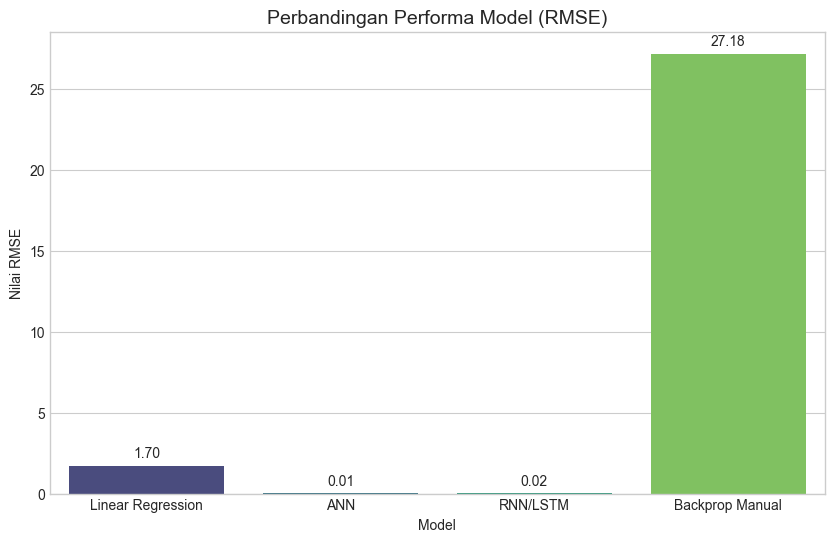

In [16]:
# --- Prediksi untuk Testing ---
X_test_bp_scaled = (X_test.values - X_mean) / X_std
layer1_test = sigmoid(np.dot(X_test_bp_scaled, W1) + b1)
y_pred_bp_scaled = np.dot(layer1_test, W2) + b2

# Kembalikan ke skala harga asli
y_pred_bp_final = (y_pred_bp_scaled * y_std) + y_mean

# Cek & Bersihkan NaN jika masih ada (sebagai pengaman terakhir)
y_pred_bp_final = np.nan_to_num(y_pred_bp_final, nan=y_mean)

# --- Hitung Metrik Evaluasi ---
models_eval = {
    'Linear Regression': {
        'MAE': mean_absolute_error(y_test, y_pred_lr),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr))
    },
    'ANN': {
        'MAE': mean_absolute_error(y_test_dl, ann_model.predict(X_test_dl, verbose=0)),
        'RMSE': np.sqrt(mean_squared_error(y_test_dl, ann_model.predict(X_test_dl, verbose=0)))
    },
    'RNN/LSTM': {
        'MAE': mean_absolute_error(y_test_dl, lstm_model.predict(X_test_lstm, verbose=0)),
        'RMSE': np.sqrt(mean_squared_error(y_test_dl, lstm_model.predict(X_test_lstm, verbose=0)))
    },
    'Backprop Manual': {
        'MAE': mean_absolute_error(y_test, y_pred_bp_final),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_bp_final))
    }
}

# Convert ke DataFrame
df_comparison = pd.DataFrame(models_eval).T.reset_index().rename(columns={'index': 'Model'})

display(df_comparison)

# --- Plotting ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='RMSE', data=df_comparison, palette='viridis')

# Tambahkan label angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Perbandingan Performa Model (RMSE)', fontsize=14)
plt.ylabel('Nilai RMSE')
plt.show()

XIII. PENYIMPANAN MODEL (MODEL SERIALIZATION)

Penjelasan: Menyimpan model ke dalam format file (.pkl dan .h5) agar bisa dipanggil nanti oleh aplikasi Web Flask/FastAPI.

In [17]:
import joblib
import os

# Membuat direktori models jika belum ada
if not os.path.exists('../models'):
    os.makedirs('../models')

# 1. Simpan model Scikit-Learn (Linear Regression & K-Means)
joblib.dump(lr_model, '../models/linear_regression_model.pkl')
joblib.dump(kmeans, '../models/kmeans_model.pkl')

# 2. Simpan Scaler (Penting agar data input di web discaling dengan parameter yang sama)
joblib.dump(scaler, '../models/scaler.pkl')

# 3. Simpan model Deep Learning (TensorFlow/Keras)
ann_model.save('../models/ann_model.h5')
lstm_model.save('../models/lstm_model.h5')

print("Berhasil! Semua model telah tersimpan di folder '/models/'.")
print("Daftar file:")
print(os.listdir('../models'))

Berhasil! Semua model telah tersimpan di folder '/models/'.
Daftar file:
['ann_model.h5', 'kmeans_model.pkl', 'linear_regression_model.pkl', 'lstm_model.h5', 'scaler.pkl']
